# Opportunity: what a user is worth, what churn costs, and what the survey data can (not) tell us

This notebook holds **all the code and calculations** for [oportunity.md](oportunity.md), which holds the analysis and conclusions.

**Three parts.**

1. **Value per user and churn cost (a first quantification).** What each customer is worth to the platform per year, what the customers behind low
   survey ratings citing *waiting time* or *problem not resolved* represent, what their churn would cost, and whether the low ratings
   have any observable consequence.
2. **The main problem with the survey data**, based on comment and rating.
3. **Something not done before:** relate the **density of comment reasons** (waiting time, problem not resolved, unclear explanation) to
   **days to resolution**. Surveys and complaints share no interaction key, so the link is tested at agent, month and customer level.

Descriptive only, no model. Nothing is imputed or invented. Assumptions are stated where they enter. No row-level customer data is displayed.

## 1. Setup and load

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
from IPython.display import display

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
DATA_DIRECTORY = REPO_ROOT / "data" / "data"
SURVEYS_ROOT = REPO_ROOT / "data" / "satisfaction_surveys"
COMPLAINTS_ROOT = REPO_ROOT / "data" / "complaints"
TRANSACTIONS_ROOT = REPO_ROOT / "data" / "transactions"

BAR_COLOR = "#2E6DB4"
MUTED_COLOR = "#6B7280"
REFERENCE_DATE = pd.Timestamp("2026-06-17")
WINDOW_START, WINDOW_END = pd.Timestamp("2025-06-01"), pd.Timestamp("2026-06-01")
CREDIT_PRODUCT_TYPES = ["Tarjeta Crédito", "Préstamo Personal", "Préstamo Hipotecario"]
DEPOSIT_PRODUCT_TYPES = ["Cuenta Ahorro", "Cuenta Corriente"]
NEGATIVE_COMMENT_THEMES = {
    "Tardaron mucho en atenderme.": "waiting time",
    "Tuve que esperar demasiado tiempo.": "waiting time",
    "No resolvieron mi problema completamente.": "problem not resolved",
    "No estoy satisfecho con la solución.": "problem not resolved",
    "El agente no fue muy claro en sus explicaciones.": "unclear explanation",
}
REASONS = ["waiting time", "problem not resolved", "unclear explanation"]


def current_memory_mb() -> float:
    """Measures the resident memory of this notebook's process.

    Exists to show the analysis stays small on a machine with limited free RAM.

    Args:
        None.

    Returns:
        float: resident set size in megabytes.
    """
    return psutil.Process().memory_info().rss / 1e6


def read_partitions(root: Path, pattern: str, columns: list[str]) -> pd.DataFrame:
    """Reads every daily file of a partitioned dataset, keeping only the needed columns.

    Exists so each dataset is loaded the same way and without unused columns.

    Args:
        root: Dataset folder containing year=/month=/day= partitions.
        pattern: File name pattern of the daily files.
        columns: Columns to keep.

    Returns:
        pd.DataFrame: all daily files stacked.
    """
    files = sorted(root.glob(f"year=*/month=*/day=*/{pattern}"))
    return pd.concat((pd.read_csv(path, usecols=columns) for path in files), ignore_index=True)


memory_start_mb = current_memory_mb()
surveys = read_partitions(SURVEYS_ROOT, "satisfaction_surveys_*.csv", [
    "survey_date", "process_date", "customer_id", "agent_id", "survey_type", "send_channel", "main_score",
    "question_1_response", "question_2_response", "question_3_response", "open_comments", "comment_sentiment", "response_time_hours",
])
surveys["survey_date"] = pd.to_datetime(surveys["survey_date"])
surveys["process_date"] = pd.to_datetime(surveys["process_date"])
complaints = read_partitions(COMPLAINTS_ROOT, "complaints_*.csv", [
    "complaint_id", "customer_id", "creation_date", "resolution_date", "resolution_days", "compensation_granted", "assigned_agent_id", "status", "origin_interaction_id",
])
complaints["creation_date"] = pd.to_datetime(complaints["creation_date"])
complaints["resolution_date"] = pd.to_datetime(complaints["resolution_date"])
customers = pd.read_csv(
    DATA_DIRECTORY / "customers.csv",
    usecols=["customer_id", "segment", "country", "customer_status", "registration_date", "credit_score", "estimated_monthly_income"],
    parse_dates=["registration_date"],
)
display(pd.Series({
    "surveys": len(surveys), "complaints": len(complaints), "customers": len(customers),
    "process memory before / after loading, MB": f"{memory_start_mb:,.0f} / {current_memory_mb():,.0f}",
}, name="value").to_frame())

,value
surveys,212759
complaints,67095
customers,150000
"process memory before / after loading, MB",128 / 240


### Exchange rates implied by the transactions file, and customer value inputs

In [2]:
june_files = sorted((TRANSACTIONS_ROOT / "year=2026" / "month=06").glob("day=*/transactions_*.csv"))
recorded = pd.concat((pd.read_csv(p, usecols=["currency", "amount", "amount_usd"]) for p in june_files), ignore_index=True).dropna(subset=["amount_usd"])
UNITS_PER_USD = (recorded["amount"] / recorded["amount_usd"]).groupby(recorded["currency"]).median().round(2).to_dict()
UNITS_PER_USD["USD"] = 1.0

product_values = pd.read_csv(DATA_DIRECTORY / "products.csv", usecols=["customer_id", "product_type", "currency", "current_balance", "interest_rate"])
product_values["balance_usd"] = product_values["current_balance"] / product_values["currency"].map(UNITS_PER_USD)
is_credit = product_values["product_type"].isin(CREDIT_PRODUCT_TYPES)
is_deposit = product_values["product_type"].isin(DEPOSIT_PRODUCT_TYPES)
product_values["credit_balance_usd"] = product_values["balance_usd"].where(is_credit, 0.0)
product_values["deposit_balance_usd"] = product_values["balance_usd"].where(is_deposit, 0.0)
product_values["annual_interest_income_usd"] = product_values["credit_balance_usd"] * product_values["interest_rate"].fillna(0) / 100
customer_value = product_values.groupby("customer_id")[["credit_balance_usd", "deposit_balance_usd", "annual_interest_income_usd"]].sum()
display(pd.Series(UNITS_PER_USD, name="units per USD").to_frame())

,units per USD
ARS,350.00
COP,"4,000.00"
USD,1.00


### Customer activity by month (streamed, one daily file at a time)

In [3]:
customer_index = pd.Index(customers["customer_id"])
MONTHS = pd.period_range("2023-06", "2026-06", freq="M")
month_number = {str(month): number for number, month in enumerate(MONTHS)}


def monthly_transactions(path: Path) -> pd.DataFrame:
    """Counts one daily file's transactions per customer and month.

    Exists so customer activity over time can be built from the full history without holding it in memory.

    Args:
        path: Path of one daily transactions file.

    Returns:
        pd.DataFrame: customer code, month number and number of transactions.
    """
    frame = pd.read_csv(path, usecols=["customer_id", "transaction_date"])
    grouped = frame.groupby([customer_index.get_indexer(frame["customer_id"]), frame["transaction_date"].str[:7].map(month_number)]).size()
    grouped.index.names = ["customer_code", "month_number"]
    return grouped.rename("transactions").reset_index()


parts = [monthly_transactions(path) for path in sorted(TRANSACTIONS_ROOT.glob("year=*/month=*/day=*/transactions_*.csv"))]
monthly = pd.concat(parts, ignore_index=True).groupby(["customer_code", "month_number"], as_index=False)["transactions"].sum()
del parts
activity = np.zeros((len(customers), len(MONTHS)), dtype=np.int32)
activity[monthly["customer_code"].to_numpy(), monthly["month_number"].to_numpy()] = monthly["transactions"].to_numpy()
cumulative = activity.cumsum(axis=1)
display(pd.Series({"months": len(MONTHS), "transactions counted": int(activity.sum()), "process memory, MB": current_memory_mb()}, name="value").to_frame())

,value
months,37.00
transactions counted,"4,425,008.00"
"process memory, MB",430.94


## 2. What is a user worth?

The files hold **no revenue, fees or margin**, so the value of a user is a **floor** built from what exists:

- **Annual interest income proxy** = credit balance x `interest_rate` (assumed to be an annual percentage). It includes delinquent balances, so it can overstate income.
- **Balances held** (credit and deposits, USD-equivalent at the implied exchange rates), which leave with the customer.
- **Activity** (transactions in the last 12 months), **tenure**, **segment**, **credit score** and **status** from `customers.csv`.

In [4]:
profile = customers.merge(customer_value, on="customer_id", how="left")
value_columns = ["credit_balance_usd", "deposit_balance_usd", "annual_interest_income_usd"]
profile[value_columns] = profile[value_columns].fillna(0.0)
profile["total_balance_usd"] = profile["credit_balance_usd"] + profile["deposit_balance_usd"]
profile["has_credit"] = profile["credit_balance_usd"] > 0
profile["tenure_years"] = (REFERENCE_DATE - profile["registration_date"]).dt.days / 365.25
first_month, end_month = month_number["2025-06"], month_number["2026-05"] + 1
profile["transactions_last_12_months"] = activity[customer_index.get_indexer(profile["customer_id"]), first_month:end_month].sum(axis=1)

SEGMENT_ORDER = ["Basic", "Plus", "Premium", "Student"]
profile["segment"] = pd.Categorical(profile["segment"], SEGMENT_ORDER, ordered=True)
by_segment = profile.groupby("segment", observed=True).agg(
    customers=("customer_id", "size"), share_with_credit_pct=("has_credit", lambda s: s.mean() * 100),
    mean_interest_income_usd=("annual_interest_income_usd", "mean"), median_interest_income_usd=("annual_interest_income_usd", "median"),
    mean_credit_balance_usd=("credit_balance_usd", "mean"), mean_deposit_balance_usd=("deposit_balance_usd", "mean"),
    mean_transactions_12m=("transactions_last_12_months", "mean"), mean_tenure_years=("tenure_years", "mean"),
    mean_credit_score=("credit_score", "mean"),
)
by_segment.loc["All"] = [
    len(profile), profile["has_credit"].mean() * 100, profile["annual_interest_income_usd"].mean(), profile["annual_interest_income_usd"].median(),
    profile["credit_balance_usd"].mean(), profile["deposit_balance_usd"].mean(), profile["transactions_last_12_months"].mean(),
    profile["tenure_years"].mean(), profile["credit_score"].mean(),
]
display(by_segment.rename_axis("value per customer (USD-eq), by segment"))

with_credit = profile[profile["has_credit"]]
display(pd.Series({
    "customers with a credit product": len(with_credit),
    "annual interest income proxy per customer WITH credit: mean": with_credit["annual_interest_income_usd"].mean(),
    "annual interest income proxy per customer WITH credit: median": with_credit["annual_interest_income_usd"].median(),
    "total annual interest income proxy, whole base": profile["annual_interest_income_usd"].sum(),
    "total balances held (credit + deposits), whole base": profile["total_balance_usd"].sum(),
    "mean balances per customer (credit + deposits)": profile["total_balance_usd"].mean(),
}, name="value").to_frame())

percentiles = [0.1, 0.25, 0.5, 0.75, 0.9, 0.99]
display(pd.DataFrame({
    "annual interest income proxy": profile["annual_interest_income_usd"].quantile(percentiles),
    "total balances": profile["total_balance_usd"].quantile(percentiles),
}).rename_axis("percentile of customers (USD-eq)"))
top_decile_share = profile.sort_values("annual_interest_income_usd", ascending=False)["annual_interest_income_usd"].head(len(profile) // 10).sum() / profile["annual_interest_income_usd"].sum() * 100
display(pd.Series({"share of the base's interest income held by the top 10% of customers (%)": top_decile_share}, name="value").to_frame())

,customers,share_with_credit_pct,mean_interest_income_usd,median_interest_income_usd,mean_credit_balance_usd,mean_deposit_balance_usd,mean_transactions_12m,mean_tenure_years,mean_credit_score
"value per customer (USD-eq), by segment",,,,,,,,,
Basic,"89,756.00",57.68,997.15,212.74,"8,464.11","5,699.90",9.87,4.00,599.54
Plus,"37,547.00",57.88,983.55,216.16,"8,359.39","5,705.87",9.87,4.01,699.18
Premium,"15,207.00",57.78,"1,001.14",215.61,"8,505.44","5,584.40",9.75,4.00,797.40
Student,"7,490.00",57.08,978.45,189.63,"8,307.07","5,768.55",9.79,4.01,649.02
All,"150,000.00",57.71,993.22,212.87,"8,434.25","5,693.11",9.85,4.00,647.10


,value
customers with a credit product,"86,561.00"
annual interest income proxy per customer WITH credit: mean,"1,721.13"
annual interest income proxy per customer WITH credit: median,713.66
"total annual interest income proxy, whole base","148,982,535.11"
"total balances held (credit + deposits), whole base","2,119,103,567.30"
mean balances per customer (credit + deposits),"14,127.36"


,annual interest income proxy,total balances
percentile of customers (USD-eq),,
0.10,0.00,0.00
0.25,0.00,"2,941.24"
0.50,212.87,"7,128.56"
0.75,841.69,"13,053.62"
0.90,"2,325.34","22,828.98"
0.99,"12,336.78","138,154.32"


,value
share of the base's interest income held by the top 10% of customers (%),66.21


,customers,mean_interest_income_usd,mean_total_balance_usd,mean_transactions_12m
value by tenure_band,,,,
< 2 y,37452,990.67,"14,155.42",9.88
2-4 y,37551,986.62,"14,003.61",9.87
4-6 y,37303,992.61,"14,115.78",9.87
6-8 y,37603,"1,003.35","14,239.32",9.79


,customers,mean_interest_income_usd,mean_total_balance_usd,mean_transactions_12m
value by score_band,,,,
"(0.0, 550.0]",8463,"1,014.22","14,406.61",10.08
"(550.0, 600.0]",31364,"1,000.17","14,134.03",9.89
"(600.0, 650.0]",35538,"1,001.68","14,173.80",9.86
"(650.0, 700.0]",22647,984.60,"14,188.97",9.76
"(700.0, 750.0]",14747,993.51,"14,162.80",9.95
"(750.0, 900.0]",14749,996.98,"14,068.14",9.74
no score,22492,968.25,"13,893.14",9.80


,customers,mean_interest_income_usd,mean_total_balance_usd,mean_transactions_12m
value by customer_status,,,,
Active,127700,998.53,"14,199.76",9.86
Closed,2979,"1,001.04","14,010.85",9.77
Inactive,14914,966.19,"13,749.39",9.79
Suspended,4407,925.37,"13,387.17",9.80


,annual_interest_income_usd,total_balance_usd
Spearman with customer value,,
annual_interest_income_usd,1.00,0.50
total_balance_usd,0.50,1.00
transactions_last_12_months,0.39,0.61
tenure_years,-0.00,-0.00
credit_score,-0.00,-0.00


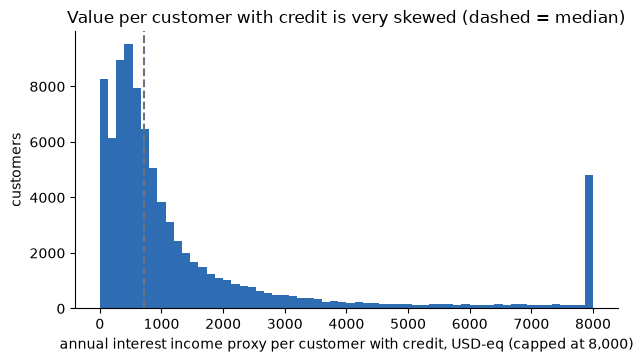

In [5]:
profile["tenure_band"] = pd.cut(profile["tenure_years"], [0, 2, 4, 6, 8, 9], labels=["< 2 y", "2-4 y", "4-6 y", "6-8 y", "8+ y"])
profile["score_band"] = pd.cut(profile["credit_score"], [0, 550, 600, 650, 700, 750, 900]).astype(str).where(profile["credit_score"].notna(), "no score")
for group in ["tenure_band", "score_band", "customer_status"]:
    display(profile.groupby(group, observed=True).agg(
        customers=("customer_id", "size"), mean_interest_income_usd=("annual_interest_income_usd", "mean"),
        mean_total_balance_usd=("total_balance_usd", "mean"), mean_transactions_12m=("transactions_last_12_months", "mean"),
    ).rename_axis(f"value by {group}"))
display(profile[["annual_interest_income_usd", "total_balance_usd", "transactions_last_12_months", "tenure_years", "credit_score"]]
        .corr(method="spearman")[["annual_interest_income_usd", "total_balance_usd"]].rename_axis("Spearman with customer value"))

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(with_credit["annual_interest_income_usd"].clip(upper=8000), bins=60, color=BAR_COLOR)
ax.axvline(with_credit["annual_interest_income_usd"].median(), color=MUTED_COLOR, linestyle="--")
ax.set_xlabel("annual interest income proxy per customer with credit, USD-eq (capped at 8,000)")
ax.set_ylabel("customers")
ax.set_title("Value per customer with credit is very skewed (dashed = median)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 3. Churn: what the data can say

In [6]:
status_counts = profile["customer_status"].value_counts()
customer_years = profile["tenure_years"].sum()
closed = status_counts.get("Closed", 0)
closed_or_inactive = closed + status_counts.get("Inactive", 0)
churn_rate_closed = closed / customer_years
churn_rate_soft = closed_or_inactive / customer_years
display(pd.Series({
    "customers Active / Inactive / Suspended / Closed": " / ".join(str(int(status_counts.get(s, 0))) for s in ["Active", "Inactive", "Suspended", "Closed"]),
    "customer-years observed (registration to 2026-06-17)": customer_years,
    "annual churn rate if Closed = churn (%)": churn_rate_closed * 100,
    "annual churn rate if Closed or Inactive = churn (%)": churn_rate_soft * 100,
}, name="value").to_frame())
display(profile.groupby("customer_status").agg(
    customers=("customer_id", "size"), share_with_credit_pct=("has_credit", lambda s: s.mean() * 100),
    mean_interest_income_usd=("annual_interest_income_usd", "mean"), mean_credit_balance_usd=("credit_balance_usd", "mean"),
    mean_deposit_balance_usd=("deposit_balance_usd", "mean"), mean_transactions_12m=("transactions_last_12_months", "mean"),
).rename_axis("do 'churned' customers still hold value and transact?"))

base_income, base_balances = profile["annual_interest_income_usd"].sum(), profile["total_balance_usd"].sum()
display(pd.DataFrame({
    "annual churn rate (%)": [churn_rate_closed * 100, churn_rate_soft * 100],
    "interest income lost per year at that rate": [base_income * churn_rate_closed, base_income * churn_rate_soft],
    "balances leaving per year at that rate": [base_balances * churn_rate_closed, base_balances * churn_rate_soft],
}, index=["Closed = churn", "Closed or Inactive = churn"]).rename_axis("whole base at the observed churn rates (weak: see the status check above)"))

,value
customers Active / Inactive / Suspended / Closed,127700 / 14914 / 4407 / 2979
customer-years observed (registration to 2026-06-17),"600,153.49"
annual churn rate if Closed = churn (%),0.50
annual churn rate if Closed or Inactive = churn (%),2.98


,customers,share_with_credit_pct,mean_interest_income_usd,mean_credit_balance_usd,mean_deposit_balance_usd,mean_transactions_12m
do 'churned' customers still hold value and transact?,,,,,,
Active,127700,57.78,998.53,"8,504.60","5,695.16",9.86
Closed,2979,56.46,"1,001.04","8,308.90","5,701.96",9.77
Inactive,14914,57.78,966.19,"8,057.33","5,692.07",9.79
Suspended,4407,56.09,925.37,"7,755.95","5,631.22",9.80


,annual churn rate (%),interest income lost per year at that rate,balances leaving per year at that rate
whole base at the observed churn rates (weak: see the status check above),,,
Closed = churn,0.50,"739,509.11","10,518,658.37"
Closed or Inactive = churn,2.98,"4,441,771.23","63,179,038.03"


`customer_status` has no date and the customers marked `Closed` or `Inactive` still hold the same value and transact as `Active` ones, so **churn is not
identifiable** in this data. The rates above are the best available approximation, not a measurement.

## 4. The customers behind low ratings: exposure, consequences and cost

**Scope and definitions.** CSAT and CES surveys (both scale 1-4, so "rated above 3" is exactly the top score 4). Ratings of 1-3 are grouped by the reason their
comment gives; the comparison baseline is the customers who gave the **top score (4)**. Window for exposure: 2025-06-01 to 2026-05-31.

In [7]:
REASON_GROUPS = REASONS + ["rated 1-3, no reason recorded", "top score (4)"]
surveys["is_low_rating"] = surveys["main_score"].isin([1, 2, 3])
surveys["theme"] = surveys["open_comments"].map(NEGATIVE_COMMENT_THEMES)
scale_1_to_4 = surveys[surveys["survey_type"].isin(["CSAT", "CES"])].copy()
scale_1_to_4["reason_group"] = np.select(
    [scale_1_to_4["main_score"] == 4, scale_1_to_4["theme"].notna(), scale_1_to_4["is_low_rating"]],
    ["top score (4)", scale_1_to_4["theme"].fillna(""), "rated 1-3, no reason recorded"], default="",
)
scale_1_to_4["reason_group"] = pd.Categorical(scale_1_to_4["reason_group"], REASON_GROUPS, ordered=True)
scale_1_to_4 = scale_1_to_4.merge(
    profile[["customer_id", "customer_status", "credit_balance_usd", "deposit_balance_usd", "annual_interest_income_usd"]], on="customer_id", how="left")
scale_1_to_4["is_not_active"] = scale_1_to_4["customer_status"] != "Active"
display(scale_1_to_4["reason_group"].value_counts().reindex(REASON_GROUPS).to_frame("CSAT and CES surveys"))

in_window = (scale_1_to_4["process_date"] >= WINDOW_START) & (scale_1_to_4["process_date"] < WINDOW_END)
window = scale_1_to_4[in_window]
distinct_customers = window.drop_duplicates(["customer_id", "reason_group"])
exposure = distinct_customers.groupby("reason_group", observed=True).agg(
    customers=("customer_id", "size"), deposit_balance_usd=("deposit_balance_usd", "sum"),
    credit_balance_usd=("credit_balance_usd", "sum"), annual_interest_income_usd=("annual_interest_income_usd", "sum"),
)
exposure["surveys_in_window"] = window.groupby("reason_group", observed=True).size()
exposure["interest_income_per_customer_usd"] = exposure["annual_interest_income_usd"] / exposure["customers"]
display(exposure.rename_axis("Tier 1, exposure: value tied to the customers of the last 12 months (USD-eq)"))

,CSAT and CES surveys
reason_group,
waiting time,25237
problem not resolved,25210
unclear explanation,12422
"rated 1-3, no reason recorded",69293
top score (4),16929


,customers,deposit_balance_usd,credit_balance_usd,annual_interest_income_usd,surveys_in_window,interest_income_per_customer_usd
"Tier 1, exposure: value tied to the customers of the last 12 months (USD-eq)",,,,,,
waiting time,8086,"45,787,368.70","67,680,024.31","7,922,600.08",8331,979.79
problem not resolved,8079,"45,263,924.78","71,562,732.42","8,171,272.26",8309,"1,011.42"
unclear explanation,4168,"23,389,736.17","35,890,646.62","4,150,893.36",4223,995.90
"rated 1-3, no reason recorded",21296,"121,167,555.30","180,323,296.46","21,224,516.90",22929,996.64
top score (4),5534,"31,424,536.86","48,529,035.99","5,618,264.88",5646,"1,015.23"


In [8]:
CHURN_REASONS = ["waiting time", "problem not resolved"]
reason_customers = distinct_customers[distinct_customers["reason_group"].isin(CHURN_REASONS)][["customer_id", "reason_group"]].merge(
    profile[["customer_id", "annual_interest_income_usd", "credit_balance_usd", "deposit_balance_usd"]], on="customer_id", how="left")
scenario = reason_customers.groupby("reason_group", observed=True).agg(
    customers=("customer_id", "size"), annual_interest_income_usd=("annual_interest_income_usd", "sum"),
    credit_balance_usd=("credit_balance_usd", "sum"), deposit_balance_usd=("deposit_balance_usd", "sum"),
)
scenario.loc["either reason (each customer once)"] = reason_customers.drop_duplicates("customer_id").agg({
    "customer_id": "size", "annual_interest_income_usd": "sum", "credit_balance_usd": "sum", "deposit_balance_usd": "sum"}).to_numpy()
scenario["interest income per customer"] = scenario["annual_interest_income_usd"] / scenario["customers"]
scenario["share of the whole base's interest income (%)"] = scenario["annual_interest_income_usd"] / base_income * 100
scenario["balances that would leave"] = scenario["credit_balance_usd"] + scenario["deposit_balance_usd"]
scenario["lost over 3 years if all churn"] = scenario["annual_interest_income_usd"] * 3
scenario["lost over 5 years if all churn"] = scenario["annual_interest_income_usd"] * 5
scenario["lost per year per 1% churning"] = scenario["annual_interest_income_usd"] * 0.01
scenario["expected loss per year at the observed churn rate (Closed or Inactive)"] = scenario["annual_interest_income_usd"] * churn_rate_soft
display(scenario.rename_axis("full-churn scenario for the customers behind the low ratings (USD-eq)"))

,customers,annual_interest_income_usd,credit_balance_usd,deposit_balance_usd,interest income per customer,share of the whole base's interest income (%),balances that would leave,lost over 3 years if all churn,lost over 5 years if all churn,lost per year per 1% churning,expected loss per year at the observed churn rate (Closed or Inactive)
full-churn scenario for the customers behind the low ratings (USD-eq),,,,,,,,,,,
waiting time,"8,086.00","7,922,600.08","67,680,024.31","45,787,368.70",979.79,5.32,"113,467,393.01","23,767,800.23","39,613,000.39","79,226.00","236,204.71"
problem not resolved,"8,079.00","8,171,272.26","71,562,732.42","45,263,924.78","1,011.42",5.48,"116,826,657.20","24,513,816.77","40,856,361.29","81,712.72","243,618.64"
either reason (each customer once),"15,715.00","15,636,931.00","135,190,749.38","88,612,328.01",995.03,10.50,"223,803,077.39","46,910,792.99","78,184,654.99","156,369.31","466,200.08"


In [9]:
def share_with_interval(frame: pd.DataFrame, flag: str, group: str) -> pd.DataFrame:
    """Computes the share of a yes/no outcome per group with a 95% half-width.

    Exists so the outcomes of each reason group can be compared with the top-score baseline on identical terms.

    Args:
        frame: Surveys carrying the outcome flag and the group column.
        flag: Name of the boolean outcome column.
        group: Name of the grouping column.

    Returns:
        pd.DataFrame: surveys, share (%) and 95% half-width (points) per group.
    """
    grouped = frame[flag].astype(float).groupby(frame[group], observed=True).agg(["size", "mean"])
    half_width = 1.96 * (grouped["mean"] * (1 - grouped["mean"]) / grouped["size"]) ** 0.5
    return pd.DataFrame({"surveys": grouped["size"], "share_pct": grouped["mean"] * 100, "ci_pts": half_width * 100})


def difference_with_interval(frame: pd.DataFrame, column: str, group: str, baseline: str) -> pd.DataFrame:
    """Computes each group's mean minus the baseline group's mean, with a 95% half-width of the difference.

    Exists to turn an observed difference into a cost only when it is distinguishable from zero.

    Args:
        frame: Rows carrying the outcome column and the group column.
        column: Numeric outcome.
        group: Grouping column.
        baseline: Group used as the comparison (the top score).

    Returns:
        pd.DataFrame: size, mean, difference versus baseline and its 95% half-width, per group.
    """
    stats = frame.groupby(group, observed=True)[column].agg(["size", "mean", "var"])
    base = stats.loc[baseline]
    stats["difference"] = stats["mean"] - base["mean"]
    stats["ci_of_difference"] = 1.96 * (stats["var"] / stats["size"] + base["var"] / base["size"]) ** 0.5
    return stats[["size", "mean", "difference", "ci_of_difference"]]


display(share_with_interval(scale_1_to_4, "is_not_active", "reason_group").rename_axis("Tier 2a: customer status other than Active, by reason group"))

,surveys,share_pct,ci_pts
"Tier 2a: customer status other than Active, by reason group",,,
waiting time,25237,15.00,0.44
problem not resolved,25210,14.83,0.44
unclear explanation,12422,15.04,0.63
"rated 1-3, no reason recorded",69293,15.05,0.27
top score (4),16929,15.05,0.54


In [10]:
survey_month = scale_1_to_4["survey_date"].dt.to_period("M").astype(str).map(month_number)
customer_code = customer_index.get_indexer(scale_1_to_4["customer_id"])
usable = (survey_month >= 4) & (survey_month <= len(MONTHS) - 5) & (customer_code >= 0)
rows = scale_1_to_4[usable].copy()
month, codes = survey_month[usable].to_numpy().astype(int), customer_code[usable]
rows["transactions_before"] = cumulative[codes, month - 1] - cumulative[codes, month - 4]
rows["transactions_after"] = cumulative[codes, month + 3] - cumulative[codes, month]
rows["change_in_transactions"] = rows["transactions_after"] - rows["transactions_before"]
activity_gap = difference_with_interval(rows, "change_in_transactions", "reason_group", "top score (4)")
display(rows.groupby("reason_group", observed=True)[["transactions_before", "transactions_after"]].mean().join(
    activity_gap[["size", "mean", "difference", "ci_of_difference"]].rename(columns={"mean": "mean_change"})
).rename_axis("Tier 2b: transactions per customer, 3 months before vs after the survey"))

,transactions_before,transactions_after,size,mean_change,difference,ci_of_difference
"Tier 2b: transactions per customer, 3 months before vs after the survey",,,,,,
waiting time,2.46,2.47,20219,0.01,0.02,0.05
problem not resolved,2.44,2.41,20238,-0.03,-0.02,0.05
unclear explanation,2.43,2.42,10002,-0.01,-0.01,0.06
"rated 1-3, no reason recorded",2.45,2.45,55529,-0.00,0.00,0.04
top score (4),2.45,2.44,13641,-0.01,0.00,0.05


In [11]:
scale_1_to_4["survey_row"] = np.arange(len(scale_1_to_4))
pairs = scale_1_to_4[["survey_row", "customer_id", "survey_date"]].merge(
    complaints[["customer_id", "creation_date", "compensation_granted"]], on="customer_id", how="inner")
pairs["days_after_survey"] = (pairs["creation_date"] - pairs["survey_date"]).dt.total_seconds() / 86400
after = pairs[(pairs["days_after_survey"] > 0) & (pairs["days_after_survey"] <= 90)]
per_survey = after.groupby("survey_row").agg(complaints_90d=("creation_date", "size"), compensation_90d=("compensation_granted", "sum"))
scale_1_to_4 = scale_1_to_4.join(per_survey, on="survey_row")
scale_1_to_4[["complaints_90d", "compensation_90d"]] = scale_1_to_4[["complaints_90d", "compensation_90d"]].fillna(0)

last_survey_date = surveys["survey_date"].max()
complaint_view = scale_1_to_4[scale_1_to_4["survey_date"] <= last_survey_date - pd.Timedelta(days=90)].copy()
complaint_view["has_complaint_90d"] = complaint_view["complaints_90d"] > 0

ordered_surveys = surveys[["customer_id", "survey_date"]].sort_values(["customer_id", "survey_date"])
ordered_surveys["next_survey"] = ordered_surveys.groupby("customer_id")["survey_date"].shift(-1)
scale_1_to_4 = scale_1_to_4.merge(ordered_surveys.drop_duplicates(["customer_id", "survey_date"]), on=["customer_id", "survey_date"], how="left")
scale_1_to_4["repeat_contact_30d"] = (scale_1_to_4["next_survey"] - scale_1_to_4["survey_date"]).dt.total_seconds() / 86400 <= 30
repeat_view = scale_1_to_4[scale_1_to_4["survey_date"] <= last_survey_date - pd.Timedelta(days=30)]

display(share_with_interval(complaint_view, "has_complaint_90d", "reason_group").rename_axis("Tier 2c: filed a complaint in the 90 days after the survey"))
display(share_with_interval(repeat_view, "repeat_contact_30d", "reason_group").rename_axis("Tier 2c: another survey within 30 days (repeat contact)"))
compensation_gap = difference_with_interval(complaint_view, "compensation_90d", "reason_group", "top score (4)")
status_gap = difference_with_interval(scale_1_to_4.assign(not_active=scale_1_to_4["is_not_active"].astype(float)), "not_active", "reason_group", "top score (4)")
display(compensation_gap.rename_axis("compensation in the 90 days after: difference vs top score (raw units per survey)"))

,surveys,share_pct,ci_pts
Tier 2c: filed a complaint in the 90 days after the survey,,,
waiting time,23151,3.50,0.24
problem not resolved,23170,3.78,0.25
unclear explanation,11437,3.45,0.33
"rated 1-3, no reason recorded",63673,3.58,0.14
top score (4),15552,3.33,0.28


,surveys,share_pct,ci_pts
Tier 2c: another survey within 30 days (repeat contact),,,
waiting time,24513,3.88,0.24
problem not resolved,24545,3.78,0.24
unclear explanation,12109,4.16,0.36
"rated 1-3, no reason recorded",67385,3.84,0.15
top score (4),16489,3.68,0.29


,size,mean,difference,ci_of_difference
compensation in the 90 days after: difference vs top score (raw units per survey),,,,
waiting time,23151,0.66,-0.12,0.32
problem not resolved,23170,0.75,-0.03,0.33
unclear explanation,11437,0.66,-0.12,0.37
"rated 1-3, no reason recorded",63673,0.63,-0.15,0.28
top score (4),15552,0.78,0.00,0.37


In [12]:
surveys_in_window = window.groupby("reason_group", observed=True).size()
cost_bound = pd.DataFrame({
    "surveys, last 12 months": surveys_in_window,
    "extra compensation per survey (raw units)": compensation_gap["difference"],
    "+/- (raw units)": compensation_gap["ci_of_difference"],
    "extra compensation, 12 months (raw units)": compensation_gap["difference"] * surveys_in_window,
    "+/- 12 months (raw units)": compensation_gap["ci_of_difference"] * surveys_in_window,
    "extra not-Active share (points)": status_gap["difference"] * 100,
    "+/- (points)": status_gap["ci_of_difference"] * 100,
    "upper bound of interest income at stake (USD-eq per year)":
        exposure["customers"] * (status_gap["difference"] + status_gap["ci_of_difference"]).clip(lower=0) * exposure["interest_income_per_customer_usd"],
}).loc[REASONS]
cost_bound["upper bound as % of the exposure"] = cost_bound["upper bound of interest income at stake (USD-eq per year)"] / exposure.loc[REASONS, "annual_interest_income_usd"] * 100
display(cost_bound.T.rename_axis("Tier 3: cost bound (differences versus customers who gave the top score)"))

reason_group,waiting time,problem not resolved,unclear explanation
Tier 3: cost bound (differences versus customers who gave the top score),,,
"surveys, last 12 months","8,331.00","8,309.00","4,223.00"
extra compensation per survey (raw units),-0.12,-0.03,-0.12
+/- (raw units),0.32,0.33,0.37
"extra compensation, 12 months (raw units)",-967.18,-251.82,-527.42
+/- 12 months (raw units),"2,686.75","2,719.22","1,570.62"
extra not-Active share (points),-0.05,-0.22,-0.01
+/- (points),0.70,0.69,0.83
upper bound of interest income at stake (USD-eq per year),"51,225.85","38,817.74","33,812.15"
upper bound as % of the exposure,0.65,0.48,0.81


## 5. The main problem with the survey data: comment and rating

In [13]:
low = surveys[surveys["is_low_rating"]]
display(pd.crosstab(surveys["main_score"], surveys["comment_sentiment"].astype(str)).rename_axis(index="main_score", columns="comment_sentiment"))
display(pd.Series({
    "comments on ratings of 1-3": low["open_comments"].notna().sum(),
    "  of which one of the five negative sentences (%)": low["theme"].notna().sum() / low["open_comments"].notna().sum() * 100,
    "comments on ratings above 3": surveys.loc[~surveys["is_low_rating"], "open_comments"].notna().sum(),
    "  of which a negative sentence": surveys.loc[~surveys["is_low_rating"], "theme"].notna().sum(),
    "surveys with a sentiment but no comment": (surveys["comment_sentiment"].notna() & surveys["open_comments"].isna()).sum(),
    "surveys with a comment but no sentiment": (surveys["comment_sentiment"].isna() & surveys["open_comments"].notna()).sum(),
    "distinct comment sentences in 212,759 surveys": surveys["open_comments"].nunique(),
}, name="value").to_frame())
display(surveys.groupby("main_score")["open_comments"].agg(lambda s: s.notna().mean() * 100).to_frame("% of surveys with a comment, by rating"))

comment_sentiment,Negative,Neutral,Positive
main_score,,,
1,2485,0,0
2,22045,0,0
3,42999,0,0
4,0,3535,6954
5,0,7840,0
6,0,7716,0
7,0,7683,0


,value
comments on ratings of 1-3,"67,477.00"
of which one of the five negative sentences (%),100.00
comments on ratings above 3,"33,719.00"
of which a negative sentence,0.00
surveys with a sentiment but no comment,"5,079.00"
surveys with a comment but no sentiment,"5,018.00"
"distinct comment sentences in 212,759 surveys",13.00


,"% of surveys with a comment, by rating"
main_score,
1,47.99
2,47.56
3,47.51
4,48.26
5,47.34
6,47.19
7,47.38


In [14]:
theme_by_score = pd.crosstab(low["theme"], low["main_score"], normalize="columns").mul(100)
display(theme_by_score.rename_axis(columns="% of comments on low ratings, by rating"))
rating_band = pd.cut(surveys["main_score"], [0, 3, 7], labels=["rated 1-3", "rated above 3"])
question_means = surveys.groupby(rating_band, observed=True)[["question_1_response", "question_2_response", "question_3_response"]].mean()
display(question_means.rename_axis("mean follow-up answer (1-5), by rating band"))
wait_by_theme = surveys.dropna(subset=["theme", "question_2_response"]).groupby("theme")["question_2_response"].agg(surveys="size", mean_wait_acceptable="mean")
display(wait_by_theme.rename_axis("'was the waiting time acceptable?' by the theme of the comment"))
display(surveys.groupby("survey_type", observed=True)["main_score"].agg(surveys="size", lowest="min", highest="max", mean="mean"))
display(pd.Series({
    "complaints with an origin_interaction_id (the link to a survey's interaction)": complaints["origin_interaction_id"].notna().sum(),
    "survey agents also present as complaint agents": len(set(surveys["agent_id"]) & set(complaints["assigned_agent_id"].dropna())),
}, name="value").to_frame())

"% of comments on low ratings, by rating",1,2,3
theme,,,
problem not resolved,38.65,39.87,40.21
unclear explanation,21.20,19.76,19.69
waiting time,40.15,40.37,40.11


,question_1_response,question_2_response,question_3_response
"mean follow-up answer (1-5), by rating band",,,
rated 1-3,3.01,3.01,3.00
rated above 3,3.01,3.01,2.97


,surveys,mean_wait_acceptable
'was the waiting time acceptable?' by the theme of the comment,,
problem not resolved,10478,3.00
unclear explanation,5111,3.04
waiting time,10383,3.00


,surveys,lowest,highest,mean
survey_type,,,,
CES,21235,1,4,2.77
CSAT,127856,1,4,2.77
NPS,63668,2,7,5.31


,value
complaints with an origin_interaction_id (the link to a survey's interaction),0
survey agents also present as complaint agents,1090


**The main problem.** The comment is **not independent information**: it is a function of the rating band. Every comment on a rating of 1-3 is one of five
negative sentences and no comment above 3 is negative; the sentiment label is also fixed by the rating band; comments exist on ~47.5% of surveys at *every*
rating; the follow-up answers are unrelated to both; and the surveys cannot be linked to complaints. The "reasons" therefore cannot be verified and add nothing
beyond the rating. The evidence is in the tables above and is summarised in `oportunity.md`.

## 6. Relating the density of comment reasons to days to resolution

Reason **density** is the number of comments of a reason **per 100 surveys** of a unit (agent, month or customer window). **Days to resolution** exists only in
complaints (`resolution_days`, resolved cases). There is no interaction key between surveys and complaints, so three levels of link are tested:

- **Agent:** the 1,090 agents that appear in both files (agent ids are shared).
- **Month:** the same calendar month in both files.
- **Customer window:** a survey filed by the customer of a *resolved* complaint within 90 days after the complaint was created.

If slow resolution caused waiting-time or unresolved comments, density would rise with days to resolution at the level tested. Correlations are Spearman with a 95%
interval (Fisher z).

In [15]:
def spearman_with_interval(x: pd.Series, y: pd.Series) -> pd.Series:
    """Computes a Spearman rank correlation with an approximate 95% interval.

    Exists so every relationship is reported with its uncertainty, using the Fisher z transformation.

    Args:
        x: First variable.
        y: Second variable, aligned to x.

    Returns:
        pd.Series: number of pairs, Spearman correlation and the lower and upper 95% limits.
    """
    frame = pd.concat([x, y], axis=1).dropna()
    rho = frame.iloc[:, 0].rank().corr(frame.iloc[:, 1].rank())
    half_width = 1.96 / math.sqrt(len(frame) - 3)
    return pd.Series({"pairs": len(frame), "spearman": rho, "ci_low": math.tanh(math.atanh(rho) - half_width), "ci_high": math.tanh(math.atanh(rho) + half_width)})


for reason in REASONS:
    surveys[f"is_{reason.replace(' ', '_')}"] = surveys["theme"] == reason
RESOLVED = complaints.dropna(subset=["resolution_days"])
MINIMUM_SURVEYS, MINIMUM_RESOLVED = 30, 5

agent_surveys = surveys.groupby("agent_id", observed=True).agg(
    surveys=("main_score", "size"), **{reason: (f"is_{reason.replace(' ', '_')}", "sum") for reason in REASONS})
agent_resolution = RESOLVED.groupby("assigned_agent_id")["resolution_days"].agg(resolved_cases="size", mean_days="mean")
agent_view = agent_surveys.join(agent_resolution, how="inner")
agent_view = agent_view[(agent_view["surveys"] >= MINIMUM_SURVEYS) & (agent_view["resolved_cases"] >= MINIMUM_RESOLVED)]
for reason in REASONS:
    agent_view[f"{reason} per 100 surveys"] = agent_view[reason] / agent_view["surveys"] * 100

display(pd.Series({
    "agents in both files": len(agent_view), "surveys per agent (median)": agent_view["surveys"].median(),
    "resolved complaints per agent (median)": agent_view["resolved_cases"].median(),
    "mean days to resolution per agent: std observed": agent_view["mean_days"].std(),
}, name="value").to_frame())
display(pd.DataFrame({reason: spearman_with_interval(agent_view[f"{reason} per 100 surveys"], agent_view["mean_days"]) for reason in REASONS}).T
        .rename_axis("Spearman: reason density vs mean days to resolution, across agents"))

,value
agents in both files,"1,084.00"
surveys per agent (median),194.00
resolved complaints per agent (median),12.00
mean days to resolution per agent: std observed,2.66


,pairs,spearman,ci_low,ci_high
"Spearman: reason density vs mean days to resolution, across agents",,,,
waiting time,"1,084.00",0.02,-0.04,0.08
problem not resolved,"1,084.00",-0.00,-0.06,0.06
unclear explanation,"1,084.00",0.01,-0.05,0.07


,agents,mean_days_to_resolution,surveys,waiting time per 100,problem not resolved per 100,unclear explanation per 100,waiting time +/-,problem not resolved +/-,unclear explanation +/-
reason density by agents' speed of resolution (quartiles),,,,,,,,,
fastest 25%,271,12.28,52548,12.64,12.61,6.26,0.28,0.28,0.21
25-50%,271,14.77,53056,12.80,13.03,6.20,0.28,0.29,0.21
50-75%,271,16.48,52977,12.79,12.38,6.34,0.28,0.28,0.21
slowest 25%,271,18.95,52999,12.76,12.77,6.29,0.28,0.28,0.21


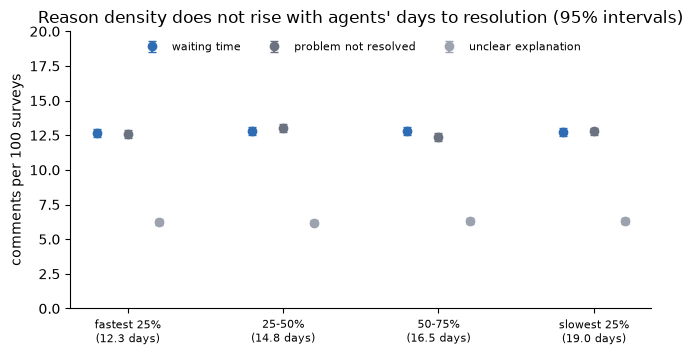

In [16]:
agent_view["resolution quartile"] = pd.qcut(agent_view["mean_days"], 4, labels=["fastest 25%", "25-50%", "50-75%", "slowest 25%"])
quartiles = agent_view.groupby("resolution quartile", observed=True).agg(
    agents=("surveys", "size"), mean_days_to_resolution=("mean_days", "mean"), surveys=("surveys", "sum"),
    **{reason: (reason, "sum") for reason in REASONS})
for reason in REASONS:
    density = quartiles[reason] / quartiles["surveys"]
    quartiles[f"{reason} per 100"] = density * 100
    quartiles[f"{reason} +/-"] = 1.96 * (density * (1 - density) / quartiles["surveys"]) ** 0.5 * 100
display(quartiles[["agents", "mean_days_to_resolution", "surveys"] + [f"{r} per 100" for r in REASONS] + [f"{r} +/-" for r in REASONS]]
        .rename_axis("reason density by agents' speed of resolution (quartiles)"))

fig, ax = plt.subplots(figsize=(7.5, 3.6))
positions = np.arange(len(quartiles))
for offset, reason, color in zip([-0.2, 0, 0.2], REASONS, [BAR_COLOR, MUTED_COLOR, "#9CA3AF"]):
    ax.errorbar(positions + offset, quartiles[f"{reason} per 100"], yerr=quartiles[f"{reason} +/-"], fmt="o", color=color, ecolor=color, capsize=3, label=reason)
ax.set_xticks(positions)
ax.set_xticklabels([f"{label}\n({days:.1f} days)" for label, days in zip(quartiles.index, quartiles["mean_days_to_resolution"])], fontsize=8)
ax.set_ylim(0, 20)
ax.set_ylabel("comments per 100 surveys")
ax.set_title("Reason density does not rise with agents' days to resolution (95% intervals)")
ax.legend(frameon=False, fontsize=8, ncol=3, loc="upper center")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [17]:
survey_month_label = surveys["process_date"].dt.to_period("M")
month_surveys = surveys.groupby(survey_month_label).agg(
    surveys=("main_score", "size"), **{reason: (f"is_{reason.replace(' ', '_')}", "sum") for reason in REASONS})
month_resolution = RESOLVED.groupby(RESOLVED["creation_date"].dt.to_period("M"))["resolution_days"].agg(resolved_cases="size", mean_days="mean")
month_view = month_surveys.join(month_resolution, how="inner").iloc[1:-1]
for reason in REASONS:
    month_view[f"{reason} per 100 surveys"] = month_view[reason] / month_view["surveys"] * 100
display(month_view[["surveys", "resolved_cases", "mean_days"] + [f"{r} per 100 surveys" for r in REASONS]].describe().rename_axis("monthly view (first and last months left out)"))
display(pd.DataFrame({reason: spearman_with_interval(month_view[f"{reason} per 100 surveys"], month_view["mean_days"]) for reason in REASONS}).T
        .rename_axis("Spearman: reason density vs mean days to resolution, across months"))

,surveys,resolved_cases,mean_days,waiting time per 100 surveys,problem not resolved per 100 surveys,unclear explanation per 100 surveys
monthly view (first and last months left out),,,,,,
count,35.00,35.00,35.00,35.00,35.00,35.00
mean,"5,899.23",426.20,15.59,12.74,12.71,6.28
std,216.35,22.61,0.39,0.40,0.47,0.31
min,"5,334.00",389.00,14.90,11.69,11.70,5.69
25%,"5,797.00",408.00,15.25,12.48,12.43,6.07
50%,"5,921.00",429.00,15.62,12.72,12.70,6.29
75%,"6,052.00",442.00,15.87,13.04,13.00,6.51
max,"6,369.00",479.00,16.43,13.54,14.00,6.86


,pairs,spearman,ci_low,ci_high
"Spearman: reason density vs mean days to resolution, across months",,,,
waiting time,35.00,0.06,-0.28,0.38
problem not resolved,35.00,0.08,-0.26,0.40
unclear explanation,35.00,-0.07,-0.40,0.27


In [18]:
survey_pairs = surveys[["customer_id", "agent_id", "survey_date", "theme"]].reset_index(drop=True).merge(
    RESOLVED[["customer_id", "creation_date", "resolution_days", "assigned_agent_id"]], on="customer_id", how="inner")
survey_pairs["days_after_complaint"] = (survey_pairs["survey_date"] - survey_pairs["creation_date"]).dt.total_seconds() / 86400
customer_window = survey_pairs[(survey_pairs["days_after_complaint"] >= 0) & (survey_pairs["days_after_complaint"] <= 90)].copy()
for reason in REASONS:
    customer_window[f"is_{reason.replace(' ', '_')}"] = customer_window["theme"] == reason
customer_window["resolution band"] = pd.cut(customer_window["resolution_days"], [0, 10, 20, 30])

window_summary = customer_window.groupby("resolution band", observed=True).agg(
    surveys=("theme", "size"), **{reason: (f"is_{reason.replace(' ', '_')}", "sum") for reason in REASONS})
for reason in REASONS:
    density = window_summary[reason] / window_summary["surveys"]
    window_summary[f"{reason} per 100"] = density * 100
    window_summary[f"{reason} +/-"] = 1.96 * (density * (1 - density) / window_summary["surveys"]) ** 0.5 * 100
display(pd.Series({
    "surveys within 90 days after a resolved complaint of the same customer": len(customer_window),
    "  distinct customers": customer_window["customer_id"].nunique(),
    "  same agent handled the complaint and the survey (%)": (customer_window["agent_id"] == customer_window["assigned_agent_id"]).mean() * 100,
}, name="value").to_frame())
display(window_summary[["surveys"] + [f"{r} per 100" for r in REASONS] + [f"{r} +/-" for r in REASONS]]
        .rename_axis("reason density by the resolution time of the customer's complaint"))
display(pd.DataFrame({reason: spearman_with_interval(customer_window[f"is_{reason.replace(' ', '_')}"].astype(float), customer_window["resolution_days"]) for reason in REASONS}).T
        .rename_axis("Spearman: has this reason vs days to resolution, customer window"))

,value
surveys within 90 days after a resolved complaint of the same customer,"1,756.00"
distinct customers,"1,631.00"
same agent handled the complaint and the survey (%),0.11


,surveys,waiting time per 100,problem not resolved per 100,unclear explanation per 100,waiting time +/-,problem not resolved +/-,unclear explanation +/-
reason density by the resolution time of the customer's complaint,,,,,,,
"(0, 10]",558,12.37,12.37,6.99,2.73,2.73,2.12
"(10, 20]",569,11.25,13.01,7.21,2.60,2.76,2.12
"(20, 30]",629,14.31,10.81,4.45,2.74,2.43,1.61


,pairs,spearman,ci_low,ci_high
"Spearman: has this reason vs days to resolution, customer window",,,,
waiting time,"1,756.00",0.02,-0.02,0.07
problem not resolved,"1,756.00",-0.03,-0.07,0.02
unclear explanation,"1,756.00",-0.04,-0.09,0.00


### 6d. Range restriction and selection: no fast resolutions, and an unresolved tail that was left out

Two limits on everything in 6a-6c, and on the earlier "no relationship" results:

1. **Range restriction.** If no complaint is ever resolved in less than a day, the data has **no observation of fast resolution**, the very thing an agent
   could deliver. A flat relationship inside the observed range says nothing about what happens below it.
2. **Selection and censoring.** `resolution_days` exists only for **resolved** complaints. Complaints that are still open have no resolution time (their wait is at
   least their age), and 6a-6c dropped them, so the longest waits were excluded.

This section measures both, and then repeats the density test **including the unresolved tail**.

In [19]:
resolved_time = complaints["resolution_days"].dropna()
gap_hours = (complaints["resolution_date"] - complaints["creation_date"]).dt.total_seconds() / 3600
display(pd.Series({
    "complaints": len(complaints),
    "with a resolution time": len(resolved_time),
    "  as % of all complaints": len(resolved_time) / len(complaints) * 100,
    "without a resolution time (open, in process, escalated, rejected or missing)": len(complaints) - len(resolved_time),
    "fastest resolution recorded, days": resolved_time.min(),
    "slowest resolution recorded, days": resolved_time.max(),
    "resolved in less than 1 day": (resolved_time < 1).sum(),
    "resolved in exactly 1 day": (resolved_time == 1).sum(),
    "resolved in 3 days or less": (resolved_time <= 3).sum(),
    "resolved in 28 days or more": (resolved_time >= 28).sum(),
    "smallest gap between creation and resolution, hours": gap_hours.min(),
}, name="value").to_frame())
display(complaints["status"].value_counts().to_frame("complaints").assign(
    with_resolution_time=complaints.groupby("status")["resolution_days"].apply(lambda s: s.notna().sum())))

,value
complaints,"67,095.00"
with a resolution time,"15,363.00"
as % of all complaints,22.90
"without a resolution time (open, in process, escalated, rejected or missing)","51,732.00"
"fastest resolution recorded, days",1.00
"slowest resolution recorded, days",30.00
resolved in less than 1 day,0.00
resolved in exactly 1 day,495.00
resolved in 3 days or less,"1,517.00"
resolved in 28 days or more,"1,592.00"


,complaints,with_resolution_time
status,,
In Process,26823,0
Open,20125,0
Resolved,13512,12871
Escalated,3321,0
Closed,2609,2492
Rejected,705,0


In [20]:
OPEN_STATUSES = ["Open", "In Process", "Escalated"]
after_complaint = surveys[["customer_id", "agent_id", "survey_date", "theme"]].merge(
    complaints[["customer_id", "creation_date", "resolution_days", "status", "assigned_agent_id"]], on="customer_id", how="inner")
after_complaint["days_after_complaint"] = (after_complaint["survey_date"] - after_complaint["creation_date"]).dt.total_seconds() / 86400
tail_window = after_complaint[(after_complaint["days_after_complaint"] >= 0) & (after_complaint["days_after_complaint"] <= 90)].copy()

OUTCOMES = ["resolved in 1-3 days", "resolved in 4-10 days", "resolved in 11-20 days", "resolved in 21-27 days", "resolved in 28-30 days",
            "never resolved (open, in process, escalated)", "rejected"]
tail_window["outcome"] = np.select(
    [tail_window["status"].isin(OPEN_STATUSES), tail_window["status"] == "Rejected", tail_window["resolution_days"] <= 3,
     tail_window["resolution_days"] <= 10, tail_window["resolution_days"] <= 20, tail_window["resolution_days"] <= 27,
     tail_window["resolution_days"] <= 30],
    OUTCOMES[5:] + OUTCOMES[:1] + OUTCOMES[1:5], default="",
)
tail_window = tail_window[tail_window["outcome"] != ""]
tail_window["outcome"] = pd.Categorical(tail_window["outcome"], OUTCOMES, ordered=True)
for reason in REASONS:
    tail_window[f"is_{reason.replace(' ', '_')}"] = tail_window["theme"] == reason

tail_summary = tail_window.groupby("outcome", observed=True).agg(
    surveys=("theme", "size"), customers=("customer_id", "nunique"),
    **{reason: (f"is_{reason.replace(' ', '_')}", "sum") for reason in REASONS})
for reason in REASONS:
    density = tail_summary[reason] / tail_summary["surveys"]
    tail_summary[f"{reason} per 100"] = density * 100
    tail_summary[f"{reason} +/-"] = 1.96 * (density * (1 - density) / tail_summary["surveys"]) ** 0.5 * 100
display(tail_summary[["surveys", "customers"] + [f"{r} per 100" for r in REASONS] + [f"{r} +/-" for r in REASONS]]
        .rename_axis("reason density in the 90 days after a complaint, by how the complaint ended"))

,surveys,customers,waiting time per 100,problem not resolved per 100,unclear explanation per 100,waiting time +/-,problem not resolved +/-,unclear explanation +/-
"reason density in the 90 days after a complaint, by how the complaint ended",,,,,,,,
resolved in 1-3 days,179,166,13.97,8.94,9.50,5.08,4.18,4.29
resolved in 4-10 days,379,351,11.61,13.98,5.80,3.23,3.49,2.35
resolved in 11-20 days,569,527,11.25,13.01,7.21,2.60,2.76,2.12
resolved in 21-27 days,424,402,13.68,11.79,4.72,3.27,3.07,2.02
resolved in 28-30 days,205,194,15.61,8.78,3.90,4.97,3.87,2.65
"never resolved (open, in process, escalated)",5592,5154,12.86,12.71,6.56,0.88,0.87,0.65
rejected,82,78,15.85,13.41,4.88,7.91,7.38,4.66


In [21]:
resolved_windows = tail_window[tail_window["outcome"].isin(OUTCOMES[:5])]
never_resolved = tail_window[tail_window["outcome"] == OUTCOMES[5]]
fast = tail_window[tail_window["outcome"] == OUTCOMES[0]]
slow = tail_window[tail_window["outcome"] == OUTCOMES[4]]


def density_gap(first: pd.DataFrame, second: pd.DataFrame, reason: str) -> pd.Series:
    """Computes the difference in the density of a reason between two survey groups, with a 95% half-width.

    Exists to test whether one group of complaints produces more comments of a reason than another.

    Args:
        first: Surveys of the first group.
        second: Surveys of the comparison group.
        reason: Reason (theme) whose density is compared.

    Returns:
        pd.Series: the two densities per 100 surveys, their difference and its 95% half-width in points.
    """
    column = f"is_{reason.replace(' ', '_')}"
    p1, p2 = first[column].mean(), second[column].mean()
    half_width = 1.96 * (p1 * (1 - p1) / len(first) + p2 * (1 - p2) / len(second)) ** 0.5
    return pd.Series({"first per 100": p1 * 100, "comparison per 100": p2 * 100, "difference (points)": (p1 - p2) * 100, "+/- (points)": half_width * 100})


display(pd.DataFrame({reason: density_gap(never_resolved, resolved_windows, reason) for reason in REASONS}).T
        .rename_axis("never resolved (first) vs resolved in 1-30 days (comparison)"))
display(pd.DataFrame({reason: density_gap(slow, fast, reason) for reason in REASONS}).T
        .rename_axis("resolved in 28-30 days (first) vs resolved in 1-3 days (comparison)"))

,first per 100,comparison per 100,difference (points),+/- (points)
never resolved (first) vs resolved in 1-30 days (comparison),,,,
waiting time,12.86,12.70,0.16,1.79
problem not resolved,12.71,12.02,0.70,1.75
unclear explanation,6.56,6.15,0.41,1.30


,first per 100,comparison per 100,difference (points),+/- (points)
resolved in 28-30 days (first) vs resolved in 1-3 days (comparison),,,,
waiting time,15.61,13.97,1.64,7.10
problem not resolved,8.78,8.94,-0.16,5.70
unclear explanation,3.90,9.50,-5.59,5.05


In [22]:
agent_complaints = complaints.dropna(subset=["assigned_agent_id"]).groupby("assigned_agent_id").agg(
    complaints=("complaint_id", "size"), still_unresolved=("status", lambda s: s.isin(OPEN_STATUSES).sum()))
agent_complaints["share_unresolved"] = agent_complaints["still_unresolved"] / agent_complaints["complaints"] * 100
agent_tail = agent_surveys.join(agent_complaints, how="inner")
agent_tail = agent_tail[(agent_tail["surveys"] >= MINIMUM_SURVEYS) & (agent_tail["complaints"] >= 10)]
for reason in REASONS:
    agent_tail[f"{reason} per 100 surveys"] = agent_tail[reason] / agent_tail["surveys"] * 100
display(pd.Series({
    "agents": len(agent_tail), "complaints per agent (median)": agent_tail["complaints"].median(),
    "share of an agent's complaints still unresolved: mean (%)": agent_tail["share_unresolved"].mean(),
    "  std across agents": agent_tail["share_unresolved"].std(),
}, name="value").to_frame())
display(pd.DataFrame({reason: spearman_with_interval(agent_tail[f"{reason} per 100 surveys"], agent_tail["share_unresolved"]) for reason in REASONS}).T
        .rename_axis("Spearman: reason density vs share of the agent's complaints still unresolved"))

,value
agents,"1,090.00"
complaints per agent (median),36.00
share of an agent's complaints still unresolved: mean (%),65.12
std across agents,8.03


,pairs,spearman,ci_low,ci_high
Spearman: reason density vs share of the agent's complaints still unresolved,,,,
waiting time,"1,090.00",-0.03,-0.09,0.03
problem not resolved,"1,090.00",0.03,-0.03,0.09
unclear explanation,"1,090.00",-0.04,-0.10,0.02


**Reading.**

- **The range restriction is real.** No complaint was resolved in less than a day: the fastest is exactly 1 day (495 cases; the smallest gap between
  creation and resolution is 24.00 hours) and the slowest 30. Only 1,517 of the 15,363 resolved complaints took 3 days or less. Every relationship in this
  notebook, and in the complaints analysis, therefore holds **only inside 1-30 days**. The data cannot say what same-day or first-contact resolution would
  do, which is exactly what an agent would aim for.
- **The selection is real.** Only 22.9% of complaints (15,363) have a resolution time. The other 51,732 (77.1%) have none, and no rating or
  compensation either (only `Resolved` and `Closed` cases carry them).
- **The unresolved tail shows nothing either.** Including complaints that were never resolved (5,592 surveys from 5,154 customers, open for up to three
  years), customers cite waiting time and unresolved problems no more often than after complaints resolved in 1-30 days: 12.86 vs 12.70 per 100 surveys
  (+0.16, +/-1.79) and 12.71 vs 12.02 (+0.70, +/-1.75). Agents with more unresolved complaints do not attract more of such comments (Spearman -0.03 and +0.03
  across 1,090 agents).
- **Power at the extremes is low.** Complaints resolved in 1-3 days (179 surveys) against 28-30 days (205 surveys) can only detect differences of 5-7 points per 100
  surveys (for example waiting time +1.64, +/-7.10), so nothing can be concluded about the fast end from these data.

So the reasons are unrelated to resolution time **where it is observed (1-30 days)** and to the **never-resolved tail**, but the fast end (under one day) is unobserved and the extremes are
too thin to test. The absence of a relationship must not be read as proof that speed does not matter.

## 7. Key figures for the write-up

In [23]:
key_figures = pd.Series({
    "customers": len(profile),
    "mean annual interest income proxy per customer (USD-eq)": profile["annual_interest_income_usd"].mean(),
    "mean per customer with credit": with_credit["annual_interest_income_usd"].mean(),
    "mean balances per customer": profile["total_balance_usd"].mean(),
    "whole base: annual interest income proxy / balances (USD-eq)": f"{base_income:,.0f} / {base_balances:,.0f}",
    "customers behind waiting-time or not-resolved low ratings (12 months)": scenario.loc["either reason (each customer once)", "customers"],
    "their annual interest income tied (USD-eq)": scenario.loc["either reason (each customer once)", "annual_interest_income_usd"],
    "observed annual churn rate, Closed / Closed or Inactive (%)": f"{churn_rate_closed * 100:.2f} / {churn_rate_soft * 100:.2f}",
    "peak process memory, MB": current_memory_mb(),
}, name="value")
display(key_figures.to_frame())

,value
customers,150000
mean annual interest income proxy per customer (USD-eq),993.22
mean per customer with credit,"1,721.13"
mean balances per customer,"14,127.36"
whole base: annual interest income proxy / balances (USD-eq),"148,982,535 / 2,119,103,567"
customers behind waiting-time or not-resolved low ratings (12 months),"15,715.00"
their annual interest income tied (USD-eq),"15,636,931.00"
"observed annual churn rate, Closed / Closed or Inactive (%)",0.50 / 2.98
"peak process memory, MB",633.97
